## Introduction

Customer retention is a major challenge for businesses, especially in competitive industries like telecom and banking. Customer Churn Prediction helps companies identify customers who are likely to stop using their services, allowing them to take preventive actions and improve satisfaction.

This project, “Customer Churn Prediction using Machine Learning”, focuses on building a predictive model that analyzes customer behavior and transaction data to determine the probability of churn. The goal is to assist organizations in making data-driven decisions to retain valuable customers.

**Key Steps Involved:**

* Data Preprocessing: Cleaning and transforming data for analysis.
* Feature Engineering: Selecting important features like usage patterns, payment history, and customer tenure.
* Model Building: Training algorithms such as Logistic Regression, Random Forest, and XGBoost to predict churn.
* Evaluation: Measuring performance using Accuracy, Precision, Recall, and ROC-AUC.
* Insights: Identifying factors that most influence customer churn.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [3]:
df = pd.read_csv(r'Churn_Modelling.csv')

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
X = df.drop(labels=['CustomerId', 'Surname', 'RowNumber', 'Exited'], axis = 1)
y = df['Exited']

In [6]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [7]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
label1 = LabelEncoder()
X['Geography'] = label1.fit_transform(X['Geography'])

In [10]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,Female,42,2,0.00,1,1,1,101348.88
1,608,2,Female,41,1,83807.86,1,0,1,112542.58
2,502,0,Female,42,8,159660.80,3,1,0,113931.57
3,699,0,Female,39,1,0.00,2,0,0,93826.63
4,850,2,Female,43,2,125510.82,1,1,1,79084.10


In [11]:
label = LabelEncoder()
X['Gender'] = label.fit_transform(X['Gender'])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [12]:
X = pd.get_dummies(X, drop_first=True, columns=['Geography'])
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_1,Geography_2
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


### Feature Standardization

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify = y)

In [15]:
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train

array([[-1.24021723, -1.09665089,  0.77986083, ...,  1.64099027,
        -0.57812007, -0.57504086],
       [ 0.75974873,  0.91186722, -0.27382717, ..., -1.55587522,
         1.72974448, -0.57504086],
       [-1.72725557, -1.09665089, -0.9443559 , ...,  1.1038111 ,
        -0.57812007, -0.57504086],
       ...,
       [-0.51484098,  0.91186722,  0.87565065, ..., -1.01507508,
         1.72974448, -0.57504086],
       [ 0.73902369, -1.09665089, -0.36961699, ..., -1.47887193,
        -0.57812007, -0.57504086],
       [ 0.95663657,  0.91186722, -1.32751517, ...,  0.50945854,
        -0.57812007,  1.73900686]])

### Build ANN

In [18]:
model = Sequential()
model.add(Dense(X.shape[1], activation='relu', input_dim = X.shape[1]))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [19]:
X.shape[1]

11

In [20]:
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [21]:
model.fit(X_train, y_train.to_numpy(), batch_size = 10, epochs = 10, verbose = 1)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.7923 - loss: 0.4710
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8423 - loss: 0.3767
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8527 - loss: 0.3624
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8602 - loss: 0.3474
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8622 - loss: 0.3392
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8589 - loss: 0.3415
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8654 - loss: 0.3396
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8632 - loss: 0.3310
Epoch 9/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8574 - loss: 0.3399
Epoch 10/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8613 - loss: 0.3291


### Prediction probabilities

In [22]:
y_pred_probs = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


### Convert to class labels (0 or 1)

In [23]:
y_pred = (y_pred_probs > 0.5).astype("int32")

### Accuaracy

In [24]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.8575


### Confusion Matrix

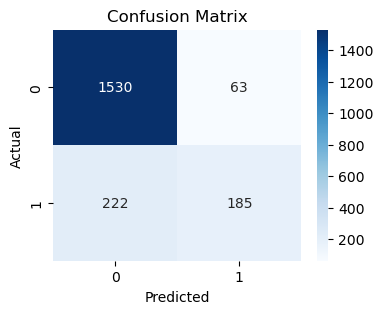

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Report

In [26]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91      1593
           1       0.75      0.45      0.56       407

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [27]:
confusion_matrix(y_test, y_pred)

array([[1530,   63],
       [ 222,  185]], dtype=int64)

In [28]:
accuracy_score(y_test, y_pred)

0.8575

In [29]:
import pickle
from tensorflow.keras.models import save_model

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save Keras ANN model
model.save('ann_model.h5')

## Conclusion

The Customer Churn Prediction project effectively demonstrates how machine learning can help businesses retain customers by predicting churn behavior with high accuracy. The developed model provides valuable insights that support better decision-making and customer engagement strategies.

**Key Highlights:**

* Accurately identifies customers at risk of leaving.
* Provides actionable insights to improve customer retention.
* Strengthens understanding of ML algorithms, feature selection, and business analytics.
* In the future, the model can be improved with Deep Learning or real-time prediction systems, making it suitable for large-scale commercial use.